<a href="https://colab.research.google.com/github/joshuajhchoi/ai2learn/blob/master/iris_decision_tree_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 다중 분류 with 결정트리 (Iris 데이터셋)

이 노트북에서는 파이썬의 scikit-learn 라이브러리를 사용하여 Iris 데이터셋에 대한 결정트리 다중 분류 모델을 구현합니다. 다음 단계를 통해 진행됩니다:

1. 필요한 라이브러리 임포트
2. 데이터셋 로드 및 탐색
3. 데이터 전처리
4. 결정트리 모델 학습
5. 모델 평가
6. 결정트리 시각화
7. 하이퍼파라미터 튜닝

## 1. 필요한 라이브러리 임포트

In [1]:
# 데이터 처리 및 분석 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn 라이브러리
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# 경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 2. 데이터셋 로드 및 탐색

In [2]:
# Iris 데이터셋 로드
iris = load_iris()
X = iris.data
y = iris.target

# 데이터셋 기본 정보 확인
print(f"데이터셋 크기: {X.shape}")
print(f"클래스 레이블: {np.unique(y)}")
print(f"클래스 이름: {iris.target_names}")
print(f"특성 이름: {iris.feature_names}")

데이터셋 크기: (150, 4)
클래스 레이블: [0 1 2]
클래스 이름: ['setosa' 'versicolor' 'virginica']
특성 이름: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [3]:
# 데이터프레임으로 변환하여 데이터 살펴보기
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(y, iris.target_names)

# 데이터 샘플 확인
print("데이터 샘플:")
iris_df.head()

데이터 샘플:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# 데이터 기술 통계량 확인
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


클래스 분포:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


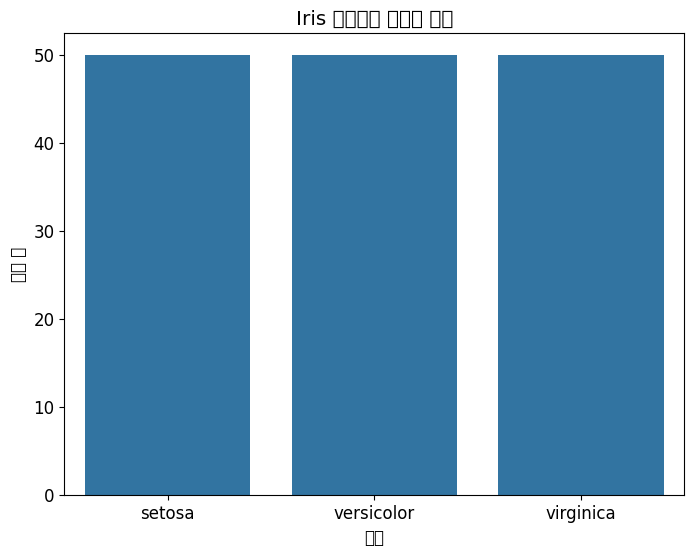

In [5]:
# 클래스 분포 확인
print("클래스 분포:")
print(iris_df['species'].value_counts())

# 클래스 분포 시각화
plt.figure(figsize=(8, 6))
sns.countplot(x='species', data=iris_df)
plt.title('Iris 데이터셋 클래스 분포')
plt.xlabel('품종')
plt.ylabel('샘플 수')
plt.show()

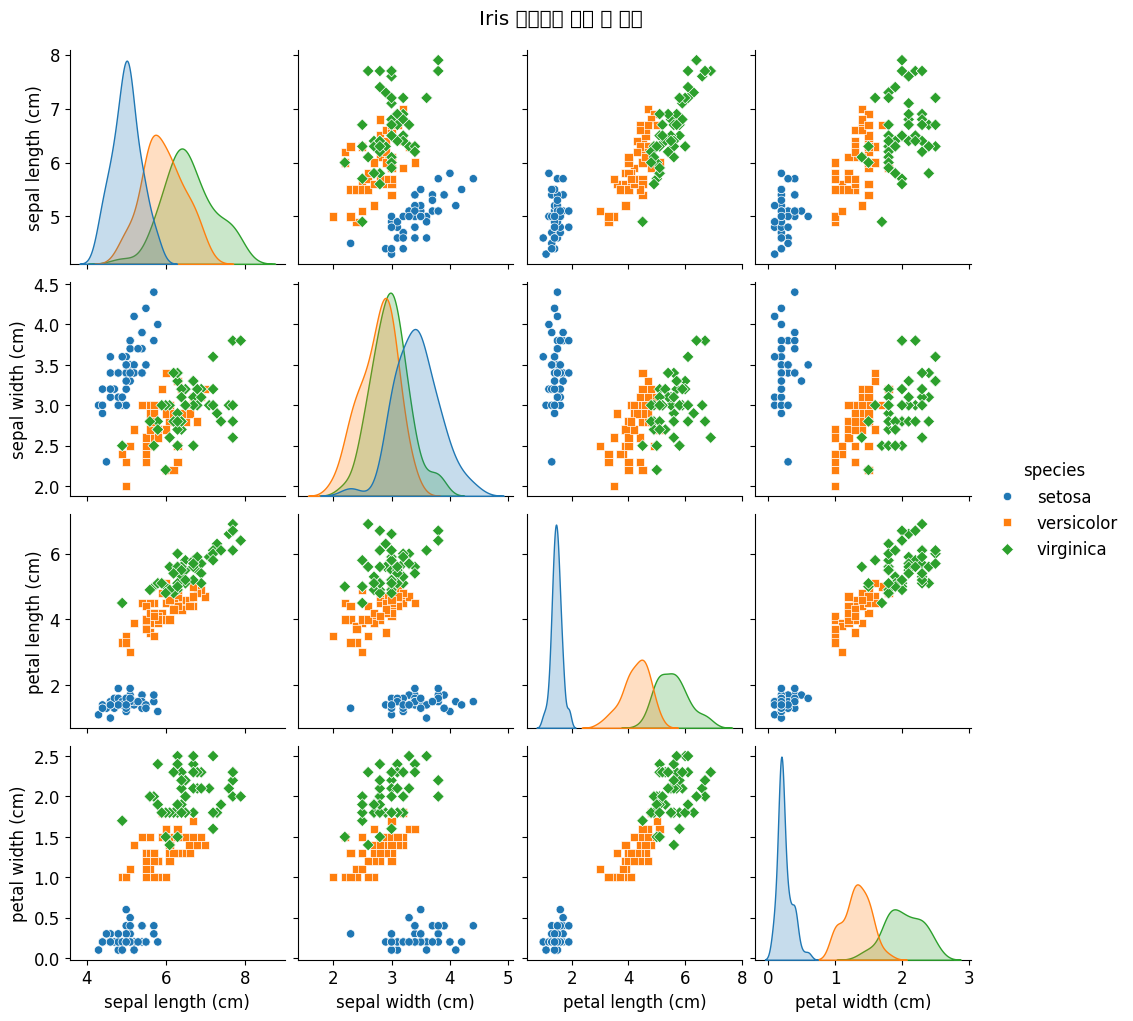

In [6]:
# 특성 간 관계 시각화 (산점도 행렬)
sns.pairplot(iris_df, hue='species', markers=['o', 's', 'D'])
plt.suptitle('Iris 데이터셋 특성 간 관계', y=1.02)
plt.show()

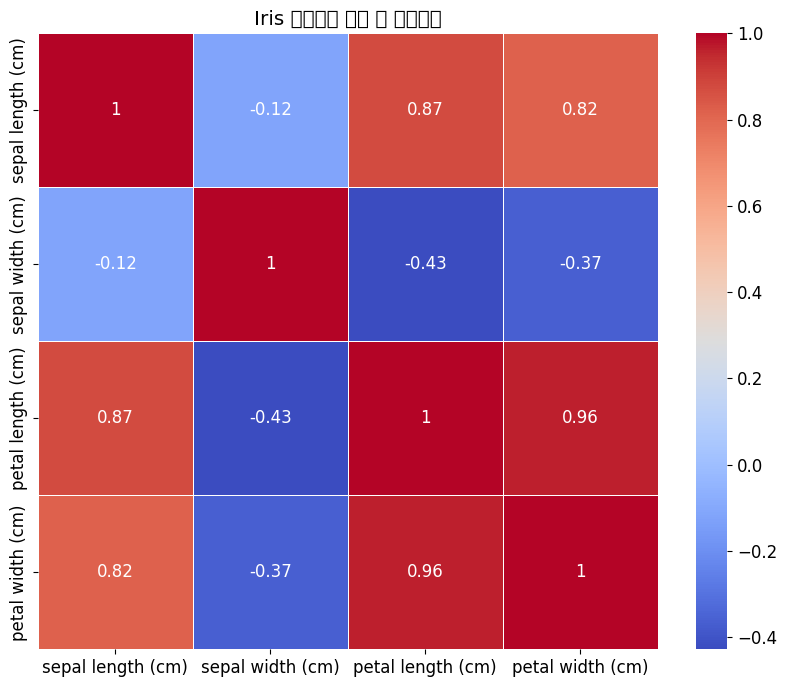

In [7]:
# 상관관계 분석
plt.figure(figsize=(10, 8))
correlation = iris_df.drop('species', axis=1).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Iris 데이터셋 특성 간 상관관계')
plt.show()

## 3. 데이터 전처리

In [8]:
# 훈련 세트와 테스트 세트로 분할 (80:20 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 분할 결과 확인
print(f"훈련 세트 크기: {X_train.shape}")
print(f"테스트 세트 크기: {X_test.shape}")

# 훈련 세트의 클래스 분포 확인
unique, counts = np.unique(y_train, return_counts=True)
print("훈련 세트 클래스 분포:", dict(zip(iris.target_names, counts)))

# 테스트 세트의 클래스 분포 확인
unique, counts = np.unique(y_test, return_counts=True)
print("테스트 세트 클래스 분포:", dict(zip(iris.target_names, counts)))

훈련 세트 크기: (120, 4)
테스트 세트 크기: (30, 4)
훈련 세트 클래스 분포: {np.str_('setosa'): np.int64(40), np.str_('versicolor'): np.int64(40), np.str_('virginica'): np.int64(40)}
테스트 세트 클래스 분포: {np.str_('setosa'): np.int64(10), np.str_('versicolor'): np.int64(10), np.str_('virginica'): np.int64(10)}


In [9]:
# 특성 스케일링 (선택 사항 - 결정트리는 스케일링에 영향을 받지 않지만 학습 목적으로 포함)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 스케일링 전후 비교
print("스케일링 전 훈련 데이터 처음 5개 샘플:")
print(X_train[:5])
print("\n스케일링 후 훈련 데이터 처음 5개 샘플:")
print(X_train_scaled[:5])

스케일링 전 훈련 데이터 처음 5개 샘플:
[[4.4 2.9 1.4 0.2]
 [4.9 2.5 4.5 1.7]
 [6.8 2.8 4.8 1.4]
 [4.9 3.1 1.5 0.1]
 [5.5 2.5 4.  1.3]]

스케일링 후 훈련 데이터 처음 5개 샘플:
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]
 [-1.12449223  0.11567567 -1.28894078 -1.45494479]
 [-0.40800161 -1.22765467  0.13059752  0.12508575]]


## 4. 결정트리 모델 학습

In [10]:
# 기본 결정트리 모델 생성 및 학습 (원본 데이터 사용)
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# 모델 정보 출력
print(f"결정트리 깊이: {dt_classifier.get_depth()}")
print(f"결정트리 노드 수: {dt_classifier.tree_.node_count}")
print(f"결정트리 리프 노드 수: {dt_classifier.tree_.n_leaves}")

결정트리 깊이: 5
결정트리 노드 수: 15
결정트리 리프 노드 수: 8


## 5. 모델 평가

In [11]:
# 훈련 세트에 대한 예측
y_train_pred = dt_classifier.predict(X_train)

# 테스트 세트에 대한 예측
y_test_pred = dt_classifier.predict(X_test)

# 정확도 평가
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"훈련 세트 정확도: {train_accuracy:.4f}")
print(f"테스트 세트 정확도: {test_accuracy:.4f}")

훈련 세트 정확도: 1.0000
테스트 세트 정확도: 0.9333


In [12]:
# 분류 보고서 (정밀도, 재현율, F1 점수)
print("테스트 세트 분류 보고서:")
print(classification_report(y_test, y_test_pred, target_names=iris.target_names))

테스트 세트 분류 보고서:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



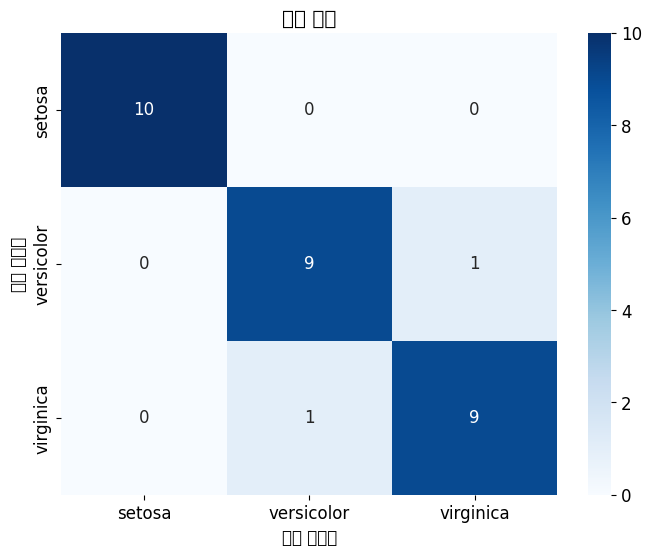

In [13]:
# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('혼동 행렬')
plt.xlabel('예측 레이블')
plt.ylabel('실제 레이블')
plt.show()

특성 중요도:
             feature  importance
2  petal length (cm)    0.558568
3   petal width (cm)    0.406015
1   sepal width (cm)    0.029167
0  sepal length (cm)    0.006250


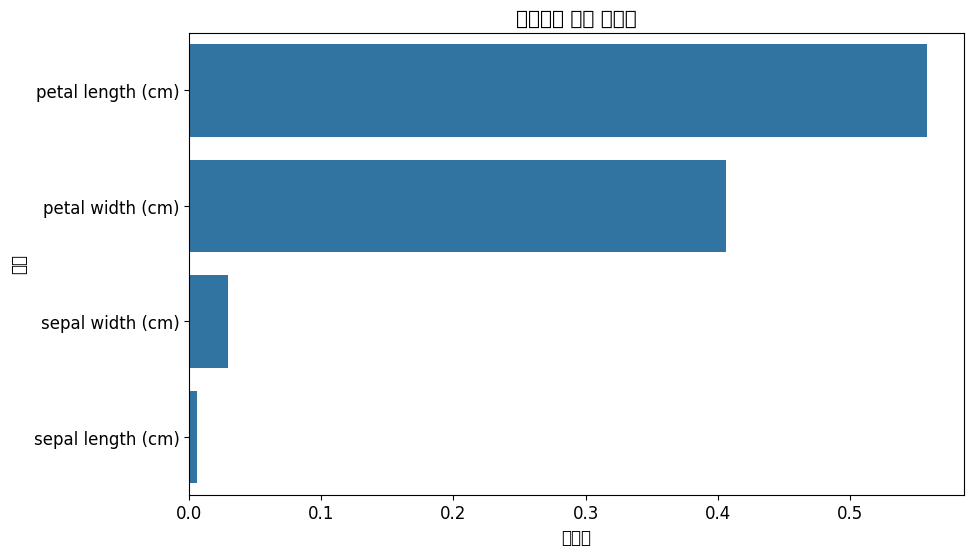

In [14]:
# 특성 중요도 확인
feature_importance = pd.DataFrame({
    'feature': iris.feature_names,
    'importance': dt_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("특성 중요도:")
print(feature_importance)

# 특성 중요도 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('결정트리 특성 중요도')
plt.xlabel('중요도')
plt.ylabel('특성')
plt.show()

## 6. 결정트리 시각화

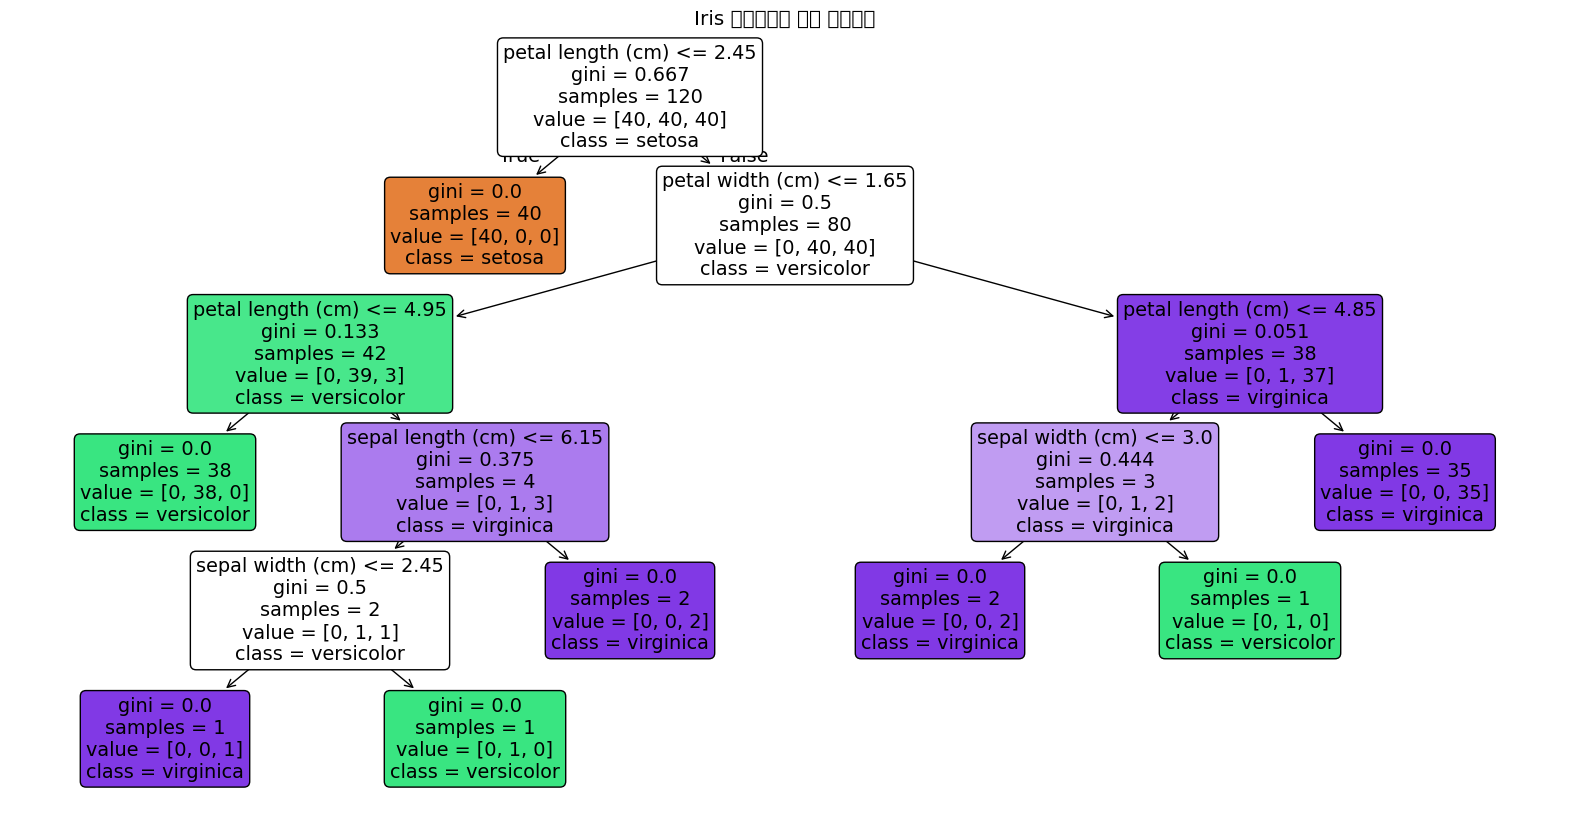

In [15]:
# 결정트리 시각화
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title('Iris 데이터셋에 대한 결정트리')
plt.show()

## 7. 하이퍼파라미터 튜닝

In [16]:
# 그리드 서치를 통한 하이퍼파라미터 튜닝
param_grid = {
    'max_depth': [None, 3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# 최적 하이퍼파라미터 및 성능 출력
print(f"최적 하이퍼파라미터: {grid_search.best_params_}")
print(f"최적 교차 검증 점수: {grid_search.best_score_:.4f}")

최적 하이퍼파라미터: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
최적 교차 검증 점수: 0.9417


In [17]:
# 최적 모델로 테스트 세트 평가
best_dt = grid_search.best_estimator_
y_test_pred_best = best_dt.predict(X_test)
best_test_accuracy = accuracy_score(y_test, y_test_pred_best)

print(f"최적 모델의 테스트 세트 정확도: {best_test_accuracy:.4f}")
print("\n최적 모델의 테스트 세트 분류 보고서:")
print(classification_report(y_test, y_test_pred_best, target_names=iris.target_names))

최적 모델의 테스트 세트 정확도: 0.9333

최적 모델의 테스트 세트 분류 보고서:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



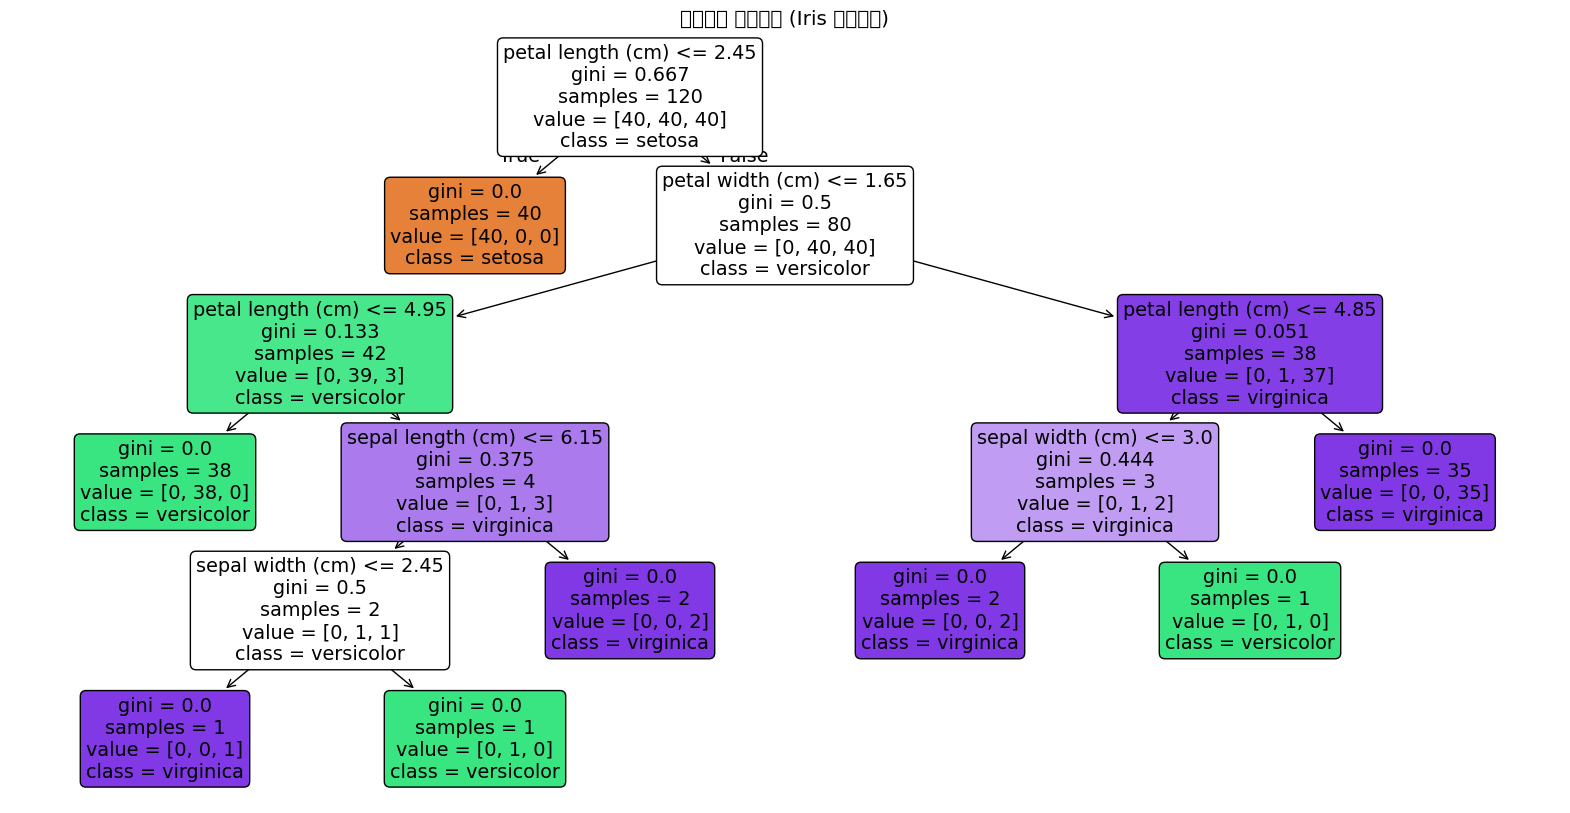

In [18]:
# 최적 모델의 결정트리 시각화
plt.figure(figsize=(20, 10))
plot_tree(best_dt, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title('최적화된 결정트리 (Iris 데이터셋)')
plt.show()

## 8. 새로운 데이터에 대한 예측

In [19]:
# 새로운 데이터 샘플 생성
new_samples = np.array([
    [5.1, 3.5, 1.4, 0.2],  # setosa와 유사
    [6.7, 3.1, 4.7, 1.5],  # versicolor와 유사
    [6.3, 3.3, 6.0, 2.5]   # virginica와 유사
])

# 예측
predictions = best_dt.predict(new_samples)
prediction_proba = best_dt.predict_proba(new_samples)

# 결과 출력
print("새로운 데이터에 대한 예측:")
for i, (sample, pred, proba) in enumerate(zip(new_samples, predictions, prediction_proba)):
    print(f"샘플 {i+1}: {sample}")
    print(f"  예측 클래스: {iris.target_names[pred]}")
    print(f"  클래스별 확률: {dict(zip(iris.target_names, proba))}")
    print()

새로운 데이터에 대한 예측:
샘플 1: [5.1 3.5 1.4 0.2]
  예측 클래스: setosa
  클래스별 확률: {np.str_('setosa'): np.float64(1.0), np.str_('versicolor'): np.float64(0.0), np.str_('virginica'): np.float64(0.0)}

샘플 2: [6.7 3.1 4.7 1.5]
  예측 클래스: versicolor
  클래스별 확률: {np.str_('setosa'): np.float64(0.0), np.str_('versicolor'): np.float64(1.0), np.str_('virginica'): np.float64(0.0)}

샘플 3: [6.3 3.3 6.  2.5]
  예측 클래스: virginica
  클래스별 확률: {np.str_('setosa'): np.float64(0.0), np.str_('versicolor'): np.float64(0.0), np.str_('virginica'): np.float64(1.0)}



## 9. 결론 및 요약

이 노트북에서는 Iris 데이터셋을 사용하여 결정트리 다중 분류 모델을 구현했습니다. 주요 단계와 결과는 다음과 같습니다:

1. **데이터 탐색**: Iris 데이터셋은 3개의 클래스(setosa, versicolor, virginica)와 4개의 특성을 가지고 있으며, 각 클래스는 균등하게 분포되어 있습니다.

2. **모델 학습**: 기본 결정트리 모델을 학습시켰으며, 하이퍼파라미터 튜닝을 통해 모델 성능을 개선했습니다.

3. **모델 평가**: 최적화된 모델은 테스트 세트에서 높은 정확도를 보였으며, 특히 setosa 클래스는 완벽하게 분류했습니다.

4. **특성 중요도**: 결정트리 모델에서 가장 중요한 특성은 꽃잎 길이(petal length)와 꽃잎 너비(petal width)로 나타났습니다.

5. **시각화**: 결정트리를 시각화하여 모델의 의사 결정 과정을 이해할 수 있었습니다.

결정트리는 해석하기 쉽고 시각화가 가능하다는 장점이 있어, 다중 분류 문제에 효과적으로 적용할 수 있습니다. 하지만 과적합 문제가 발생할 수 있으므로, 적절한 하이퍼파라미터 튜닝이 중요합니다.